In [6]:
from pinnsform.util import *
from pinnsform.model import PINN, FLS, FLW, FullWavelet
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
%matplotlib inline

def load_csv_to_numpy(file_path):
    df = pd.read_csv(file_path, header=None, index_col=None, sep=",")
    return np.array(df.values)

In [7]:
base_dir = os.getcwd()
experiment_name = "FourModels_TS_LBFGS_200"
data_path = os.path.join(base_dir, '..', 'results', experiment_name, 'run')

analysis_path = os.path.join(base_dir, 'analysis', experiment_name)

pinn_path = os.path.join(data_path, "PINN")
fls_path = os.path.join(data_path, "FLS")
flw_path = os.path.join(data_path, "FLW")
fullw_path = os.path.join(data_path, "FullWavelet")

In [10]:
problem_domain = ([0, 2*np.pi], [0, 1])
problem_name = "1Dreaction"
device='cpu'

train_points = (51, 51) 

# 51x51 mesh as list
np_mesh = generate_mesh(train_points, problem_domain)
# 51x51 mesh as list with temporal sequence for every point
sequence_mesh = make_temporal_sequence(np_mesh, num_step=5, step=1e-3)
# flatten the temporal sequence for normal models
np_mesh_sequence = listify_sequence(sequence_mesh)
# make Mesh object of torch tensors
mesh = torchify(np_mesh_sequence, device, True)
boundaries = torchified_borders(np_mesh_sequence, problem_domain, device, False)

In [18]:
device = 'cpu'

pinn = PINN(in_dim=2, hidden_dim=512, out_dim=1, num_layer=4).to(device)

fls = FLS(in_dim=2, hidden_dim=512, out_dim=1, num_layer=4).to(device)

flw = FLW(in_dim=2, hidden_dim=512, out_dim=1, num_layer=4).to(device)

fullwavelet = FullWavelet(in_dim=2, hidden_dim=512, out_dim=1, num_layer=4).to(device)

NUM_SEEDS = 100
INIT_SEEDS = np.array(range(NUM_SEEDS))

def mean_init_prediction(model, mesh):
    return np.mean(f(model, mesh).detach().cpu().numpy())

In [ ]:
def error_list(path, error_index=0):
    rmae_list = []
    for i in INIT_SEEDS:
        rmae_path = os.path.join(path, f"seed_{i}", "error.csv")
        data = load_csv_to_numpy(rmae_path)
        rmae_list.append(float(data[1,error_index]))
    return rmae_list

In [75]:
def histogram(data):
    plt.figure(figsize=(4, 3))
    # Create a histogram
    plt.hist(data, bins=np.arange(0,1.1,0.1), edgecolor='black')
    #plt.title("rMAE ")
    plt.xlabel("rMAE")
    plt.ylabel("Model Count")
    plt.grid(True)
    plt.ylim(0,100)
    # Display the plot
    plt.show()

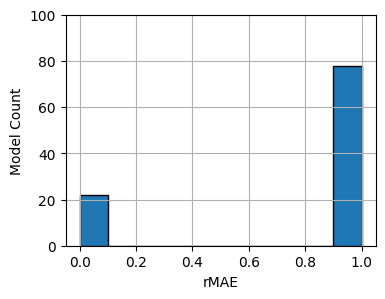

In [76]:
histogram(rMAE_list(flw_path))

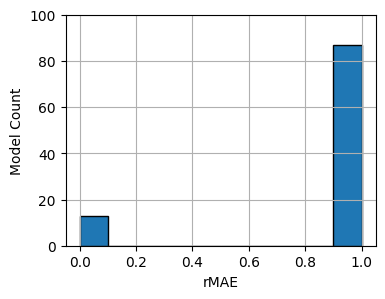

In [77]:
histogram(rMAE_list(fls_path))

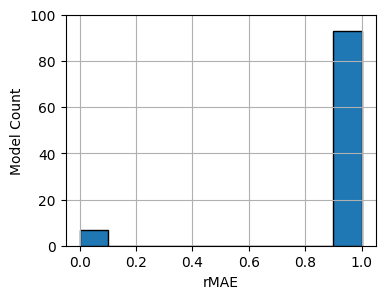

In [78]:
histogram(rMAE_list(pinn_path))

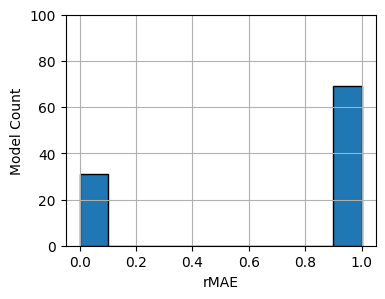

In [79]:
histogram(rMAE_list(fullw_path))